<a href="https://colab.research.google.com/github/SUMANADUTTAIEM/AIML-LAB/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/house-price-prediction")

print("Path to dataset files:", path)


100%|██████████| 132k/132k [00:00<00:00, 438kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/house-price-prediction/versions/1


In [ ]:
import pandas as pd

# Replace 'your_csv_file_name.csv' with the actual name of the CSV file in the downloaded dataset
csv_file_path = '/root/.cache/kagglehub/datasets/bhanupratapbiswas/house-price-prediction/versions/1/your_csv_file_name.csv'

try:
    df = pd.read_csv(csv_file_path)
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file {csv_file_path} was not found.")
    print("Please check the actual file name in the downloaded dataset.")

Error: The file /root/.cache/kagglehub/datasets/bhanupratapbiswas/house-price-prediction/versions/1/your_csv_file_name.csv was not found.
Please check the actual file name in the downloaded dataset.


In [ ]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Step 2: Dataset Path and Load
data_path = "/root/.cache/kagglehub/datasets/bhanupratapbiswas/house-price-prediction/versions/1"
file_name = "data.csv"  # Change this if actual file name differs

# Confirm file exists
print("\n Files in dataset folder:")
print(os.listdir(data_path))

# Load CSV
df = pd.read_csv(os.path.join(data_path, file_name))

display(df.head())


📂 Files in dataset folder:
['data.csv']


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
# Step 3: Explore the Dataset
print("\n First 5 Rows:")
print(df.head())

print("\n Dataset Info:")
print(df.info())

print("\n Statistical Summary:")
print(df.describe())

# Step 4: Check Missing Values
print("\n Missing Values:")
print(df.isnull().sum())

# Drop or fill missing values (example: fill with median)
df = df.fillna(df.median(numeric_only=True))


🔍 First 5 Rows:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated      

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


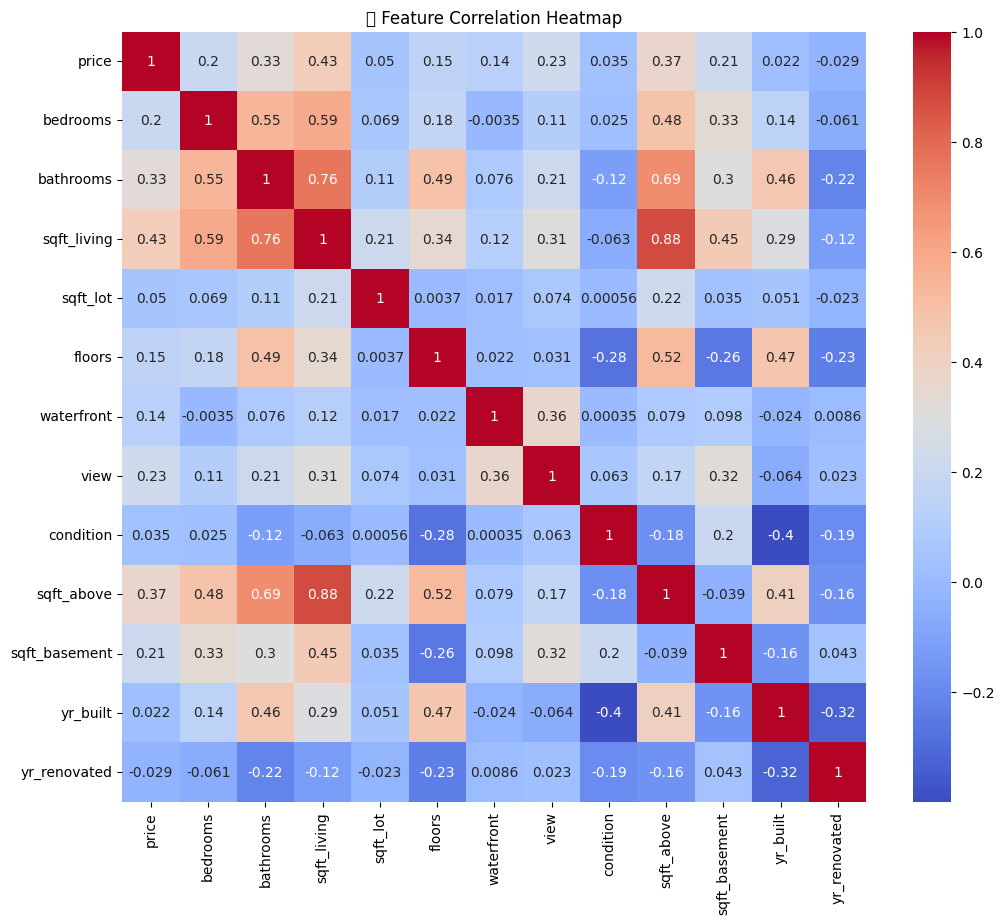

In [ ]:
# Step 5: Visualize Correlation
# Exclude non-numeric columns before calculating correlation
numeric_df = df.drop(columns=['date', 'street', 'city', 'statezip', 'country'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("🔗 Feature Correlation Heatmap")
plt.show()

# Step 6: Define Features and Target
# Replace 'price' with the actual target column name if it's different
target_column = 'price'
X = numeric_df.drop(columns=[target_column])
y = numeric_df[target_column]

# Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


📈 Model Evaluation Metrics:
R² Score: 0.032
MAE: 210908.17
MSE: 986921767056.10
RMSE: 993439.36


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


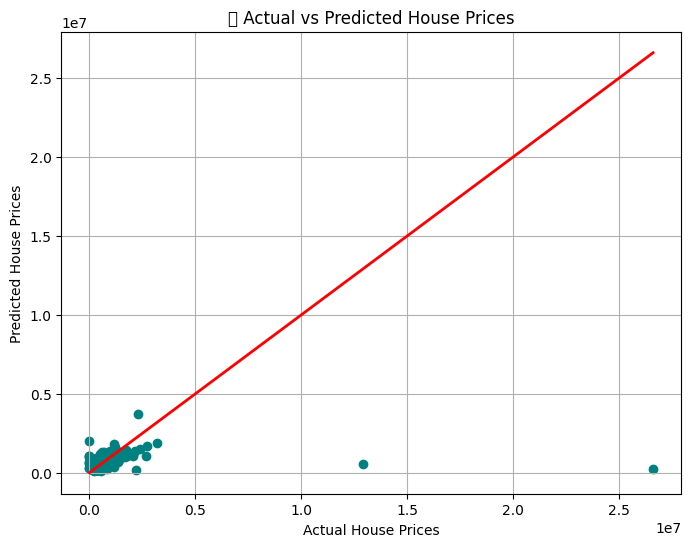

In [ ]:
# Step 8: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 9: Predict and Evaluate
y_pred = model.predict(X_test)

print("\n Model Evaluation Metrics:")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Step 10: Plot Predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(" Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

In [ ]:
print(df.columns)


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Step 1: Load dataset
data_path = "/root/.cache/kagglehub/datasets/bhanupratapbiswas/house-price-prediction/versions/1"
file_name = "data.csv"  # Make sure it's correct
df = pd.read_csv(os.path.join(data_path, file_name))

First rows:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated           

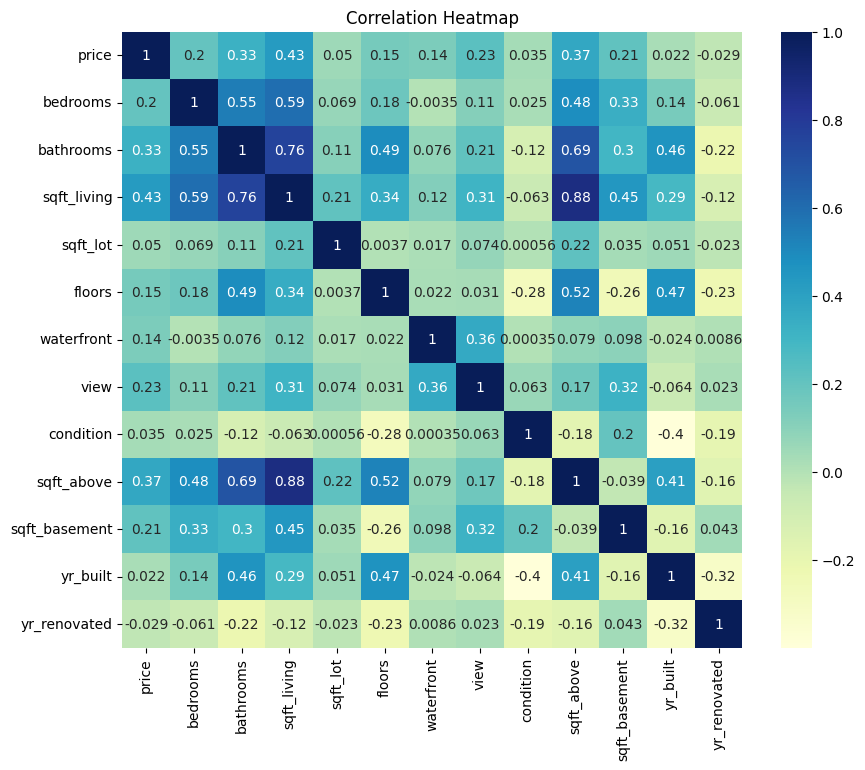

In [ ]:
# Step 2: Basic info
print("First rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

# Step 3: Fill missing values
df = df.fillna(df.median(numeric_only=True))

# Step 4: Correlation plot
# Exclude non-numeric columns before calculating correlation
numeric_df = df.drop(columns=['date', 'street', 'city', 'statezip', 'country'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Step 5: Outlier Detection (Optional)
# Remove rows where 'price' is way too high (top 1%)
threshold = df['price'].quantile(0.99)
df = df[df['price'] < threshold]

# Step 6: Feature & Target
X = df.drop(columns=['price'])
y = df['price']

# Identify categorical columns if any
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

# Step 7: Preprocessing
# For simplicity, use OneHotEncoder for categorical and keep numeric as is
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])



📊 Model Evaluation:
R² Score: 0.68
MAE: 107026.33
MSE: 27110337877.33
RMSE: 164652.17


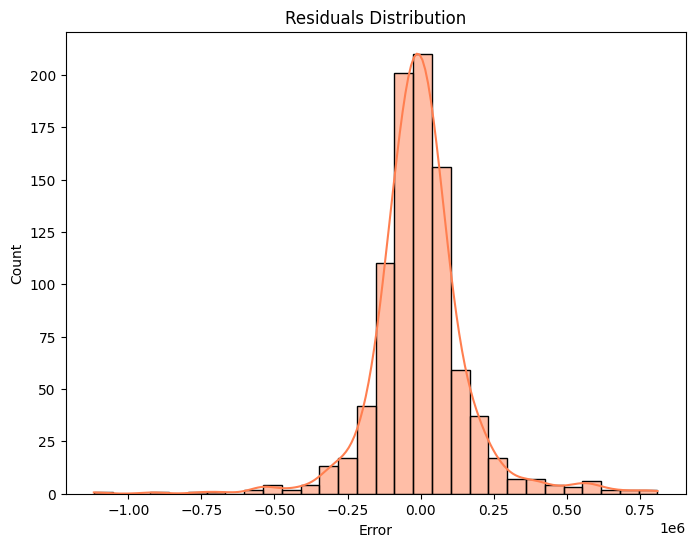

In [ ]:
# Step 8: Create a Pipeline with Linear Regression
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# Step 9: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 10: Train Model
pipeline.fit(X_train, y_train)

# Step 11: Predictions
y_pred = pipeline.predict(X_test)

# Step 12: Evaluation
print("\n📊 Model Evaluation:")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Step 13: Plot Residuals
plt.figure(figsize=(8, 6))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, bins=30, color='coral')
plt.title("Residuals Distribution")
plt.xlabel("Error")
plt.show()


In [ ]:
# Step 14: Save model
joblib.dump(pipeline, "house_price_model.pkl")
print("\n✅ Model saved as 'house_price_model.pkl'")

# Step 15: Load model (optional)
# loaded_model = joblib.load("house_price_model.pkl")

# Step 16: Predict from new user input (dynamic)
print("\n📥 Predict house price from new input:")
example = X.iloc[0].copy()

for col in X.columns:
    val = input(f"Enter value for '{col}' (default = {example[col]}): ")
    if val.strip() != "":
        try:
            if isinstance(example[col], (int, float)):
                example[col] = float(val)
            else:
                example[col] = val
        except:
            print(f"⚠️ Could not convert {val} for {col}, using default.")

# Convert single row DataFrame
new_pred = pipeline.predict(pd.DataFrame([example]))
print(f"\n Predicted House Price: ${new_pred[0]:,.2f}")


✅ Model saved as 'house_price_model.pkl'

📥 Predict house price from new input:
Enter value for 'date' (default = 2014-05-02 00:00:00): 2024
Enter value for 'bedrooms' (default = 3.0): 553
Enter value for 'bathrooms' (default = 1.5): 72729
Enter value for 'sqft_living' (default = 1340): 132
Enter value for 'sqft_lot' (default = 7912): 8972
Enter value for 'floors' (default = 1.5): 8798
Enter value for 'waterfront' (default = 0): 89
Enter value for 'view' (default = 0): 90709
Enter value for 'condition' (default = 3): 87089
Enter value for 'sqft_above' (default = 1340): 097
Enter value for 'sqft_basement' (default = 0): 87
Enter value for 'yr_built' (default = 1955): 
Enter value for 'yr_renovated' (default = 2005): 878
Enter value for 'street' (default = 18810 Densmore Ave N): 970
Enter value for 'city' (default = Shoreline): 58
Enter value for 'statezip' (default = WA 98133): 896
Enter value for 'country' (default = USA): 869

💰 Predicted House Price: $9,539,929,283.70
